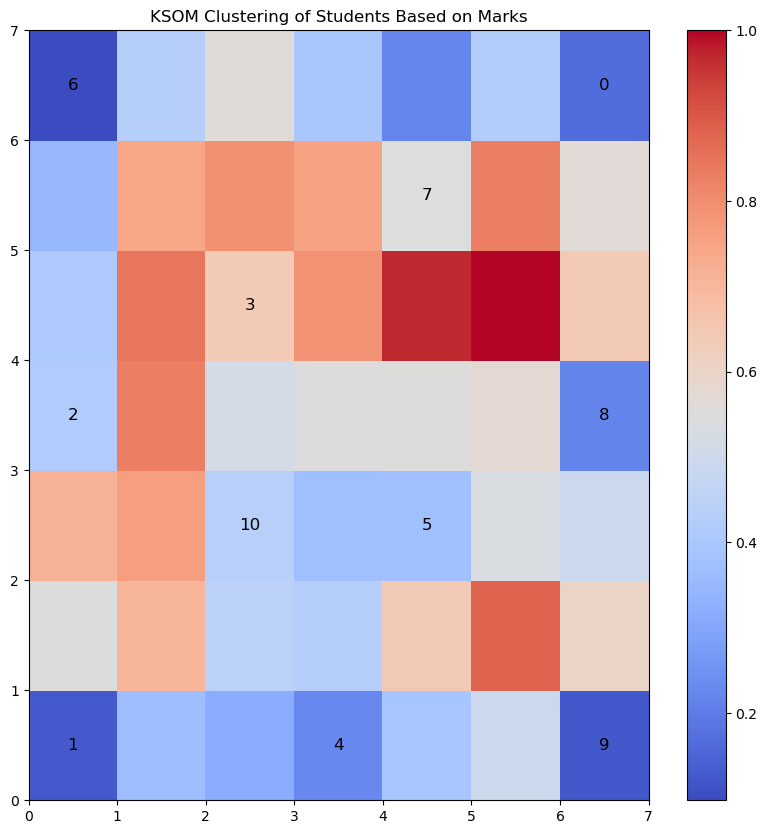

In [16]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

# Load your dataset
file_path = r"E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv"
students_data = pd.read_csv(file_path)

# Step 1: Remove 'st_id' and 'result' columns, keeping only the marks
data = students_data.drop(columns=['st_id', 'result'])

# Step 2: Normalize the data (marks)
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Step 3: Set up the KSOM model
som_x, som_y = 7, 7  # Define the dimensions of the SOM grid (e.g., 7x7 grid)
som = MiniSom(x=som_x, y=som_y, input_len=data_normalized.shape[1], sigma=1.0, learning_rate=0.5)

# Initialize the weights of the SOM
som.random_weights_init(data_normalized)

# Train the SOM (with 1000 iterations)
som.train_random(data_normalized, 1000)

# Step 4: Visualize the results
plt.figure(figsize=(10, 10))
plt.pcolor(som.distance_map().T, cmap='coolwarm')  # Distance map to show the clusters
plt.colorbar()

# Marking the winners on the SOM map
for i, x in enumerate(data_normalized):
    win = som.winner(x)
    plt.text(win[0] + 0.5, win[1] + 0.5, str(i), fontsize=12, color='black', ha='center', va='center')

plt.title('KSOM Clustering of Students Based on Marks')
plt.show()


Student Cluster Assignments:
Student 0 is mapped to cluster (6, 4)
Student 1 is mapped to cluster (0, 4)
Student 2 is mapped to cluster (3, 4)
Student 3 is mapped to cluster (3, 0)
Student 4 is mapped to cluster (0, 2)
Student 5 is mapped to cluster (1, 6)
Student 6 is mapped to cluster (4, 2)
Student 7 is mapped to cluster (5, 6)
Student 8 is mapped to cluster (0, 0)
Student 9 is mapped to cluster (6, 1)
Student 10 is mapped to cluster (2, 2)


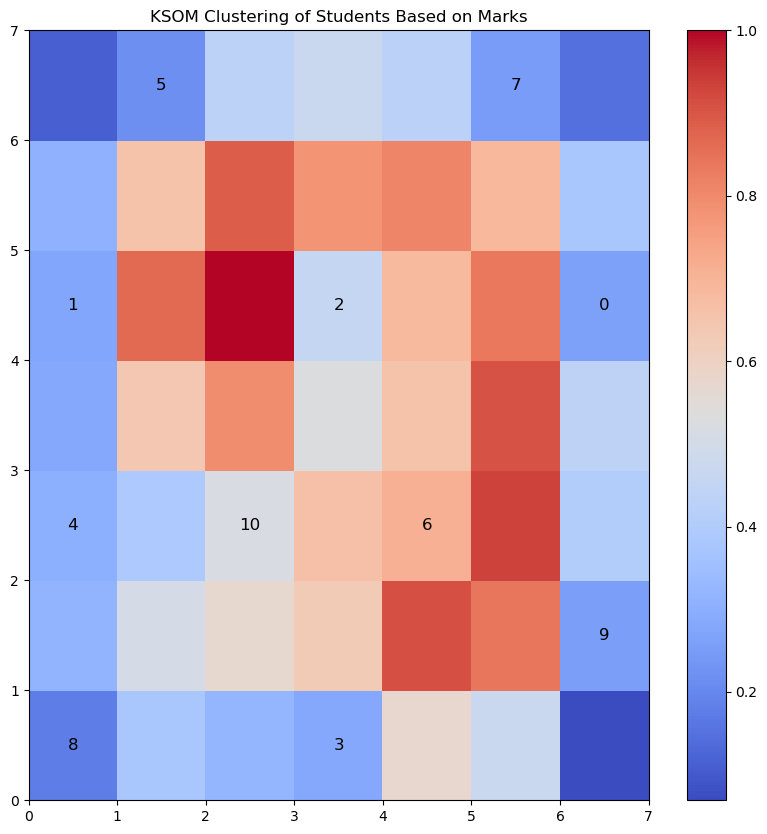

In [18]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

# Load your dataset
file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
students_data = pd.read_csv(file_path)

# Step 1: Remove 'st_id' and 'result' columns, keeping only the marks
data = students_data.drop(columns=['st_id', 'result'])

# Step 2: Normalize the data (marks)
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Step 3: Set up the KSOM model
som_x, som_y = 7, 7  # Define the dimensions of the SOM grid (e.g., 7x7 grid)
som = MiniSom(x=som_x, y=som_y, input_len=data_normalized.shape[1], sigma=1.0, learning_rate=0.5)

# Initialize the weights of the SOM
som.random_weights_init(data_normalized)

# Train the SOM (with 1000 iterations)
som.train_random(data_normalized, 1000)

# Step 4: Collect which students belong to which cluster
student_clusters = {}  # Dictionary to hold student index and their cluster coordinates

for i, x in enumerate(data_normalized):
    win = som.winner(x)  # Get the winning neuron (cluster) for each student
    student_clusters[i] = win  # Store the student index and the cluster coordinates

# Output the cluster assignment of each student
print("Student Cluster Assignments:")
for student_index, cluster_coords in student_clusters.items():
    print(f"Student {student_index} is mapped to cluster {cluster_coords}")

# Optional: Visualize the KSOM
plt.figure(figsize=(10, 10))
plt.pcolor(som.distance_map().T, cmap='coolwarm')  # Distance map to show the clusters
plt.colorbar()

# Marking the winners on the SOM map
for i, x in enumerate(data_normalized):
    win = som.winner(x)
    plt.text(win[0] + 0.5, win[1] + 0.5, str(i), fontsize=12, color='black', ha='center', va='center')

plt.title('KSOM Clustering of Students Based on Marks')
plt.show()


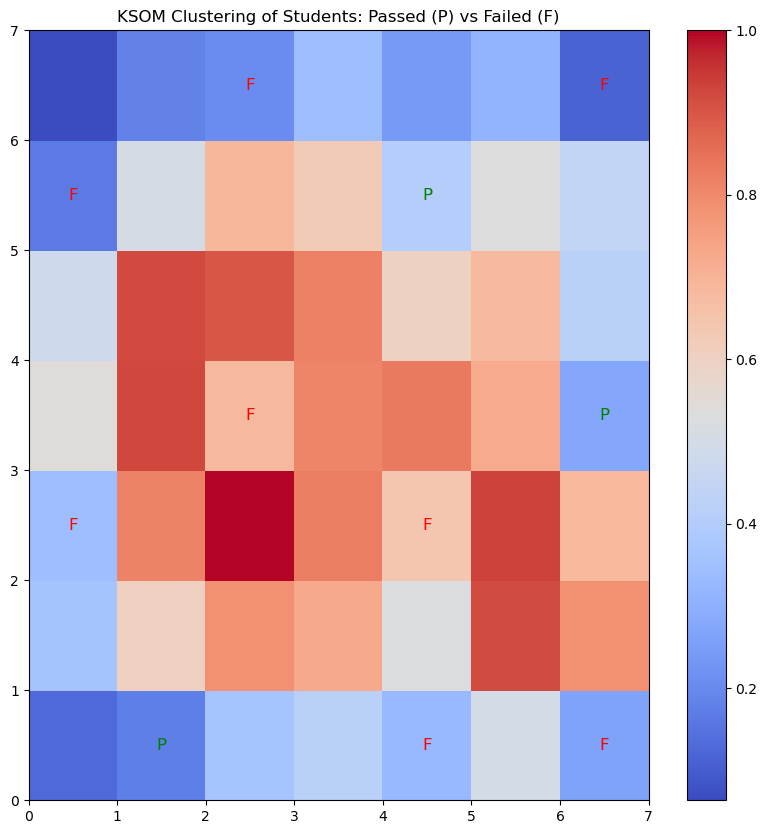

Cluster Assignments of Students:

Passed Students:
Student 1 is mapped to cluster (6, 3) (Passed)
Student 4 is mapped to cluster (1, 0) (Passed)
Student 10 is mapped to cluster (4, 5) (Passed)

Failed Students:
Student 0 is mapped to cluster (0, 2) (Failed)
Student 2 is mapped to cluster (2, 3) (Failed)
Student 3 is mapped to cluster (6, 6) (Failed)
Student 5 is mapped to cluster (0, 5) (Failed)
Student 6 is mapped to cluster (6, 0) (Failed)
Student 7 is mapped to cluster (4, 2) (Failed)
Student 8 is mapped to cluster (2, 6) (Failed)
Student 9 is mapped to cluster (4, 0) (Failed)


In [20]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

# Load your dataset
file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
students_data = pd.read_csv(file_path)

# Step 1: Remove 'st_id' column, keeping only the marks and the result
data = students_data.drop(columns=['st_id'])

# Step 2: Separate the result column (pass/fail)
results = data['result']
data = data.drop(columns=['result'])  # Keep only the marks for clustering

# Step 3: Normalize the data (marks)
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Step 4: Set up the KSOM model
som_x, som_y = 7, 7  # Define the dimensions of the SOM grid (e.g., 7x7 grid)
som = MiniSom(x=som_x, y=som_y, input_len=data_normalized.shape[1], sigma=1.0, learning_rate=0.5)

# Initialize the weights of the SOM
som.random_weights_init(data_normalized)

# Train the SOM (with 1000 iterations)
som.train_random(data_normalized, 1000)

# Step 5: Visualize the results, with passed and failed students separated
plt.figure(figsize=(10, 10))
plt.pcolor(som.distance_map().T, cmap='coolwarm')  # Distance map to show the clusters
plt.colorbar()

# Marking the pass/fail results on the SOM map
for i, x in enumerate(data_normalized):
    win = som.winner(x)  # Get the winning neuron (cluster) for each student
    if results.iloc[i] == 1:  # Assuming 1 represents 'pass'
        plt.text(win[0] + 0.5, win[1] + 0.5, 'P', fontsize=12, color='green', ha='center', va='center')  # 'P' for pass
    else:
        plt.text(win[0] + 0.5, win[1] + 0.5, 'F', fontsize=12, color='red', ha='center', va='center')  # 'F' for fail

plt.title('KSOM Clustering of Students: Passed (P) vs Failed (F)')
plt.show()

# Step 6: Output the cluster assignments of passed and failed students
student_clusters = {"Passed": [], "Failed": []}

for i, x in enumerate(data_normalized):
    win = som.winner(x)
    if results.iloc[i] == 1:  # Pass
        student_clusters["Passed"].append((i, win))  # Append student index and cluster
    else:  # Fail
        student_clusters["Failed"].append((i, win))  # Append student index and cluster

# Output the cluster assignments for passed and failed students
print("Cluster Assignments of Students:")
print("\nPassed Students:")
for student, cluster in student_clusters["Passed"]:
    print(f"Student {student} is mapped to cluster {cluster} (Passed)")

print("\nFailed Students:")
for student, cluster in student_clusters["Failed"]:
    print(f"Student {student} is mapped to cluster {cluster} (Failed)")


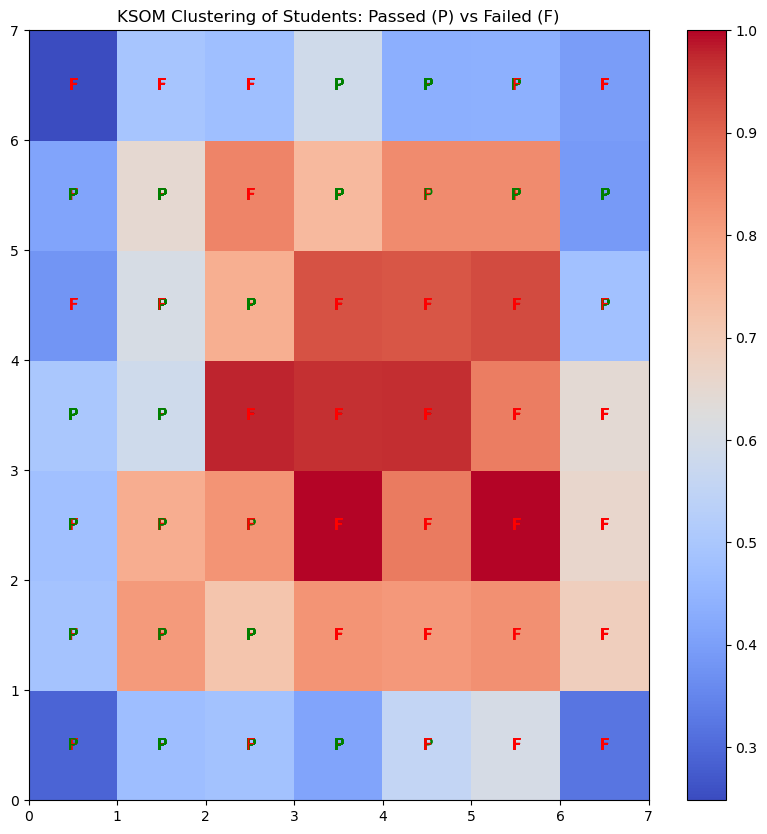

Cluster Assignments of Students:

Passed Students:
Student 0 is mapped to cluster (0, 1) (Passed)
Student 2 is mapped to cluster (0, 1) (Passed)
Student 3 is mapped to cluster (2, 1) (Passed)
Student 6 is mapped to cluster (3, 0) (Passed)
Student 8 is mapped to cluster (1, 4) (Passed)
Student 9 is mapped to cluster (0, 5) (Passed)
Student 11 is mapped to cluster (2, 1) (Passed)
Student 12 is mapped to cluster (5, 5) (Passed)
Student 13 is mapped to cluster (1, 0) (Passed)
Student 14 is mapped to cluster (0, 2) (Passed)
Student 16 is mapped to cluster (1, 5) (Passed)
Student 17 is mapped to cluster (2, 1) (Passed)
Student 19 is mapped to cluster (4, 6) (Passed)
Student 23 is mapped to cluster (2, 0) (Passed)
Student 29 is mapped to cluster (5, 6) (Passed)
Student 30 is mapped to cluster (1, 5) (Passed)
Student 31 is mapped to cluster (0, 3) (Passed)
Student 34 is mapped to cluster (1, 4) (Passed)
Student 35 is mapped to cluster (5, 5) (Passed)
Student 39 is mapped to cluster (3, 5) (Pas

In [22]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

# Load your dataset
file_path = r"E:\SRM\Soft Computing\Lab 9 - 15th Oct\training_dataset_students(1000).csv"
students_data = pd.read_csv(file_path)

# Step 1: Remove 'st_id' column, keeping only the marks and the result
data = students_data.drop(columns=['st_id'])

# Step 2: Separate the result column (pass/fail)
results = data['result']
data = data.drop(columns=['result'])  # Keep only the marks for clustering

# Step 3: Normalize the data (marks)
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Step 4: Set up the KSOM model
som_x, som_y = 7, 7  # Define the dimensions of the SOM grid (e.g., 7x7 grid)
som = MiniSom(x=som_x, y=som_y, input_len=data_normalized.shape[1], sigma=1.0, learning_rate=0.5)

# Initialize the weights of the SOM
som.random_weights_init(data_normalized)

# Train the SOM (with 1000 iterations)
som.train_random(data_normalized, 1000)

# Step 5: Visualize the results, with passed and failed students separated
plt.figure(figsize=(10, 10))
plt.pcolor(som.distance_map().T, cmap='coolwarm')  # Distance map to show the clusters
plt.colorbar()

# Marking the pass/fail results on the SOM map
for i, x in enumerate(data_normalized):
    win = som.winner(x)  # Get the winning neuron (cluster) for each student
    if results.iloc[i] == 1:  # Assuming 1 represents 'pass'
        plt.text(win[0] + 0.5, win[1] + 0.5, 'P', fontsize=12, color='green', ha='center', va='center')  # 'P' for pass
    else:
        plt.text(win[0] + 0.5, win[1] + 0.5, 'F', fontsize=12, color='red', ha='center', va='center')  # 'F' for fail

plt.title('KSOM Clustering of Students: Passed (P) vs Failed (F)')
plt.show()

# Step 6: Output the cluster assignments of passed and failed students
student_clusters = {"Passed": [], "Failed": []}

for i, x in enumerate(data_normalized):
    win = som.winner(x)
    if results.iloc[i] == 1:  # Pass
        student_clusters["Passed"].append((i, win))  # Append student index and cluster
    else:  # Fail
        student_clusters["Failed"].append((i, win))  # Append student index and cluster

# Output the cluster assignments for passed and failed students
print("Cluster Assignments of Students:")
print("\nPassed Students:")
for student, cluster in student_clusters["Passed"]:
    print(f"Student {student} is mapped to cluster {cluster} (Passed)")

print("\nFailed Students:")
for student, cluster in student_clusters["Failed"]:
    print(f"Student {student} is mapped to cluster {cluster} (Failed)")


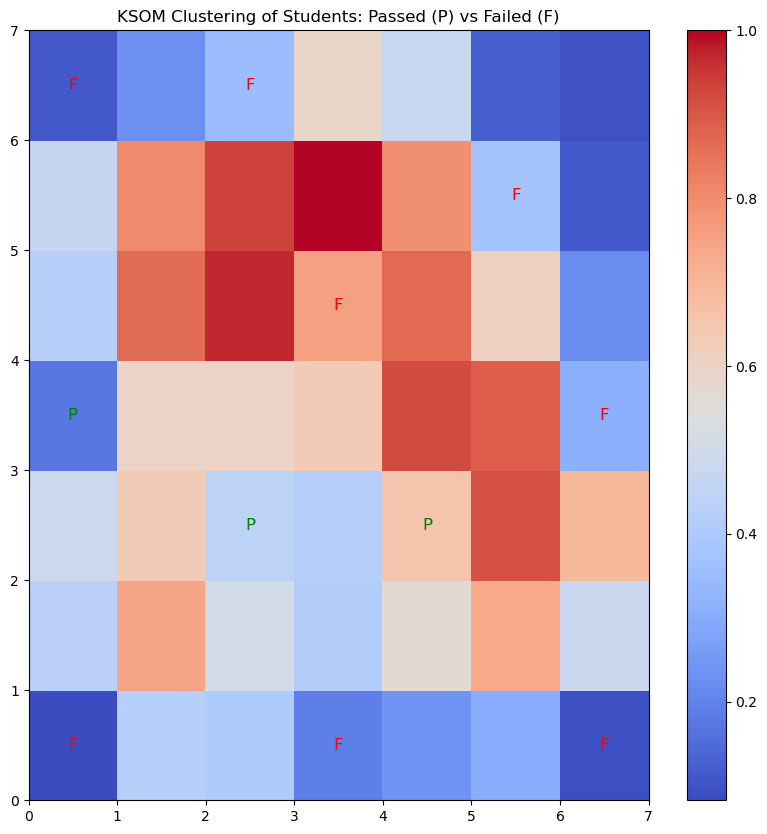

Cluster Assignments of Students:

Passed Students:
Student 1 is mapped to cluster (0, 3) (Passed)
Student 4 is mapped to cluster (4, 2) (Passed)
Student 10 is mapped to cluster (2, 2) (Passed)

Failed Students:
Student 0 is mapped to cluster (0, 6) (Failed)
Student 2 is mapped to cluster (5, 5) (Failed)
Student 3 is mapped to cluster (3, 4) (Failed)
Student 5 is mapped to cluster (3, 0) (Failed)
Student 6 is mapped to cluster (6, 3) (Failed)
Student 7 is mapped to cluster (0, 0) (Failed)
Student 8 is mapped to cluster (6, 0) (Failed)
Student 9 is mapped to cluster (2, 6) (Failed)


In [27]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

# Load your dataset
file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
students_data = pd.read_csv(file_path)

# Step 1: Remove 'st_id' column, keeping only the marks and the result
data = students_data.drop(columns=['st_id'])

# Step 2: Separate the result column (pass/fail)
results = data['result']
data = data.drop(columns=['result'])  # Keep only the marks for clustering

# Step 3: Normalize the data (marks)
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

# Step 4: Set up the KSOM model
som_x, som_y = 7, 7  # Define the dimensions of the SOM grid (e.g., 7x7 grid)
som = MiniSom(x=som_x, y=som_y, input_len=data_normalized.shape[1], sigma=1.0, learning_rate=0.5)

# Initialize the weights of the SOM
som.random_weights_init(data_normalized)

# Train the SOM (with 1000 iterations)
som.train_random(data_normalized, 1000)

# Step 5: Prepare clusters for passed and failed students
student_clusters = {"Passed": [], "Failed": []}

for i, x in enumerate(data_normalized):
    win = som.winner(x)  # Get the winning neuron (cluster) for each student
    if results.iloc[i] == 1:  # Assuming 1 represents 'pass'
        student_clusters["Passed"].append((i, win))  # Append student index and cluster for pass
    else:
        student_clusters["Failed"].append((i, win))  # Append student index and cluster for fail

# Step 6: Visualization of the clusters
plt.figure(figsize=(10, 10))
plt.pcolor(som.distance_map().T, cmap='coolwarm')  # Distance map to show the clusters
plt.colorbar()

# Marking the clusters on the SOM map
for cluster_type, students in student_clusters.items():
    for student, cluster in students:
        if cluster_type == "Passed":
            plt.text(cluster[0] + 0.5, cluster[1] + 0.5, 'P', fontsize=12, color='green', ha='center', va='center')  # 'P' for pass
        else:
            plt.text(cluster[0] + 0.5, cluster[1] + 0.5, 'F', fontsize=12, color='red', ha='center', va='center')  # 'F' for fail

plt.title('KSOM Clustering of Students: Passed (P) vs Failed (F)')
plt.show()

# Step 7: Output the cluster assignments of passed and failed students
print("Cluster Assignments of Students:")
print("\nPassed Students:")
for student, cluster in student_clusters["Passed"]:
    print(f"Student {student} is mapped to cluster {cluster} (Passed)")

print("\nFailed Students:")
for student, cluster in student_clusters["Failed"]:
    print(f"Student {student} is mapped to cluster {cluster} (Failed)")


In [1]:
import math
import pandas as pd

class SOM:

	# Function here computes the winning vector
	# by Euclidean distance
	def winner(self, weights, sample):

		D0 = 0
		D1 = 0

		for i in range(len(sample)):
			D0 = D0 + math.pow((sample[i] - weights[0][i]), 2)
			D1 = D1 + math.pow((sample[i] - weights[1][i]), 2)

		# Selecting the cluster with smallest distance as winning cluster
		if D0 < D1:
			return 0
		else:
			return 1

	# Function here updates the winning vector
	def update(self, weights, sample, J, alpha):
		# Iterating over the weights of the winning cluster and modifying them
		for i in range(len(weights[0])):
			weights[J][i] = weights[J][i] + alpha * (sample[i] - weights[J][i])

		return weights

# Driver code
def main():

	# Load training dataset
	train_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\training_dataset_students(1000).csv'
	training_data = pd.read_csv(train_file_path)
	
	# Load testing dataset
	test_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
	testing_data = pd.read_csv(test_file_path)

	# Step 1: Preprocess the data
	# Removing the 'st_id' column as it's not needed for clustering
	train_features = training_data.drop(columns=['st_id'])
	test_features = testing_data.drop(columns=['st_id'])

	# Remove the 'result' column if it exists (you can use it for testing)
	# Assuming result is the class label or pass/fail indicator (if present)
	if 'result' in train_features.columns:
		train_features = train_features.drop(columns=['result'])
	if 'result' in test_features.columns:
		test_features = test_features.drop(columns=['result'])

	# Step 2: Convert training data to a list of lists (samples)
	T = train_features.values.tolist()

	# Initialize the weights (choose random or arbitrary values)
	num_features = len(T[0])
	weights = [[0.2] * num_features, [0.8] * num_features]

	# Create SOM object
	ob = SOM()

	# Step 3: Train the SOM
	epochs = 3
	alpha = 0.5

	for epoch in range(epochs):
		for sample in T:
			# Find the winner cluster
			J = ob.winner(weights, sample)
			# Update weights for the winner
			weights = ob.update(weights, sample, J, alpha)

	# Step 4: Test the trained SOM with testing dataset
	for idx, test_sample in enumerate(test_features.values):
		# Classify each test sample based on the trained weights
		J = ob.winner(weights, test_sample)
		print(f"Test Sample {idx + 1} belongs to Cluster: {J}")

	# Output the final trained weights
	print("\nFinal trained weights:")
	for i, weight_vector in enumerate(weights):
		print(f"Cluster {i} weights: {weight_vector}")

if __name__ == "__main__":
	main()


Test Sample 1 belongs to Cluster: 1
Test Sample 2 belongs to Cluster: 0
Test Sample 3 belongs to Cluster: 1
Test Sample 4 belongs to Cluster: 1
Test Sample 5 belongs to Cluster: 0
Test Sample 6 belongs to Cluster: 0
Test Sample 7 belongs to Cluster: 1
Test Sample 8 belongs to Cluster: 1
Test Sample 9 belongs to Cluster: 0
Test Sample 10 belongs to Cluster: 1
Test Sample 11 belongs to Cluster: 0

Final trained weights:
Cluster 0 weights: [68.27677621693277, 90.17214004618558, 66.24436220347891, 66.82872631826936, 60.24276726242911, 59.303360876806266]
Cluster 1 weights: [55.30528185156491, 28.408748980246095, 39.80815772914272, 56.498159357073774, 73.09068906271806, 34.74092062646116]


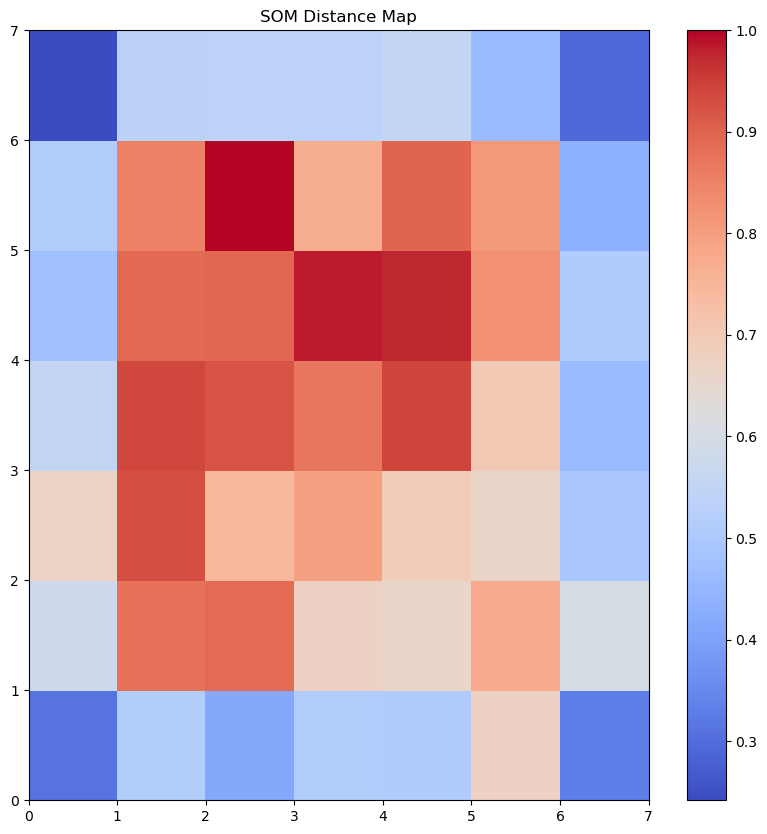

Test Sample 1 belongs to Cluster at position: (1, 0)
Test Sample 2 belongs to Cluster at position: (0, 5)
Test Sample 3 belongs to Cluster at position: (0, 2)
Test Sample 4 belongs to Cluster at position: (3, 4)
Test Sample 5 belongs to Cluster at position: (2, 0)
Test Sample 6 belongs to Cluster at position: (3, 2)
Test Sample 7 belongs to Cluster at position: (0, 2)
Test Sample 8 belongs to Cluster at position: (2, 6)
Test Sample 9 belongs to Cluster at position: (3, 2)
Test Sample 10 belongs to Cluster at position: (2, 6)
Test Sample 11 belongs to Cluster at position: (5, 2)


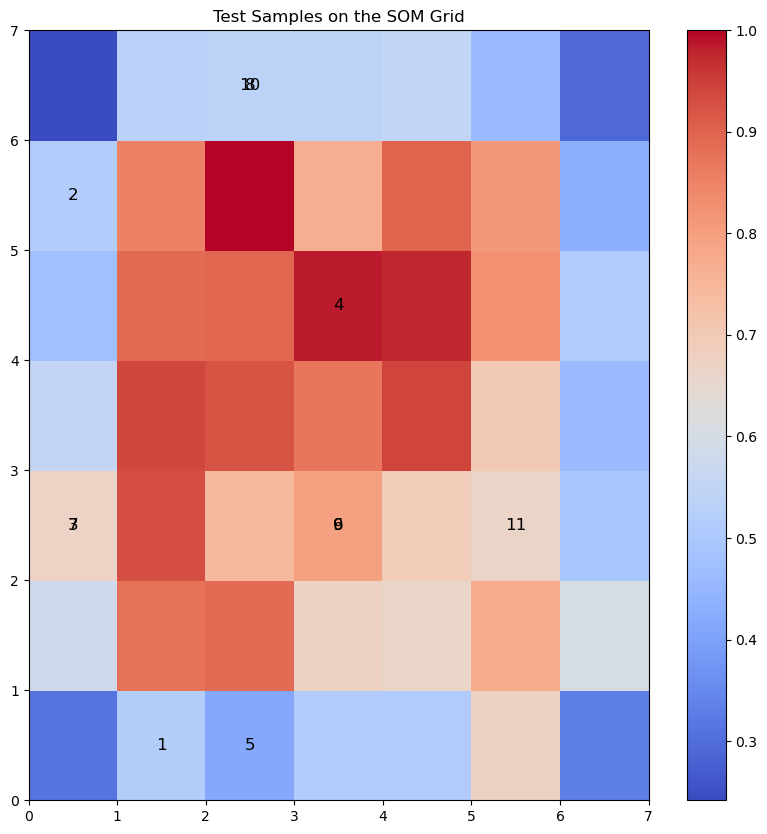

In [3]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

# Driver code
def main():

    # Load training dataset
    train_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\training_dataset_students(1000).csv'
    training_data = pd.read_csv(train_file_path)
    
    # Load testing dataset
    test_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    testing_data = pd.read_csv(test_file_path)

    # Step 1: Preprocess the data
    # Removing the 'st_id' column as it's not needed for clustering
    train_features = training_data.drop(columns=['st_id'])
    test_features = testing_data.drop(columns=['st_id'])

    # If there's a 'result' column, we remove it to focus only on marks for clustering
    if 'result' in train_features.columns:
        train_features = train_features.drop(columns=['result'])
    if 'result' in test_features.columns:
        test_features = test_features.drop(columns=['result'])

    # Step 2: Normalize the data
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_features)
    test_scaled = scaler.transform(test_features)  # Use the same scaler for test data

    # Step 3: Set up the MiniSom (Self-Organizing Map)
    som_x, som_y = 7, 7  # Size of the SOM grid
    som = MiniSom(x=som_x, y=som_y, input_len=train_scaled.shape[1], sigma=1.0, learning_rate=0.5)

    # Initialize the SOM weights and train
    som.random_weights_init(train_scaled)
    som.train_random(train_scaled, 1000)  # Train with 1000 iterations

    # Step 4: Visualize the distance map (U-Matrix) to understand clusters
    plt.figure(figsize=(10, 10))
    plt.pcolor(som.distance_map().T, cmap='coolwarm')  # SOM distance map
    plt.colorbar()
    plt.title('SOM Distance Map')
    plt.show()

    # Step 5: Testing the trained SOM on test data
    test_results = []
    for i, test_sample in enumerate(test_scaled):
        # Get the winning node (cluster) for each test sample
        winning_node = som.winner(test_sample)
        test_results.append(winning_node)
        print(f"Test Sample {i + 1} belongs to Cluster at position: {winning_node}")

    # Step 6: Display the final trained SOM clusters and color-coded test samples
    plt.figure(figsize=(10, 10))
    plt.pcolor(som.distance_map().T, cmap='coolwarm')
    plt.colorbar()

    for i, test_sample in enumerate(test_scaled):
        # Plot the test sample positions on the SOM grid
        win_position = som.winner(test_sample)
        plt.text(win_position[0] + 0.5, win_position[1] + 0.5, str(i + 1), color='black', fontsize=12, ha='center', va='center')

    plt.title('Test Samples on the SOM Grid')
    plt.show()

if __name__ == "__main__":
    main()


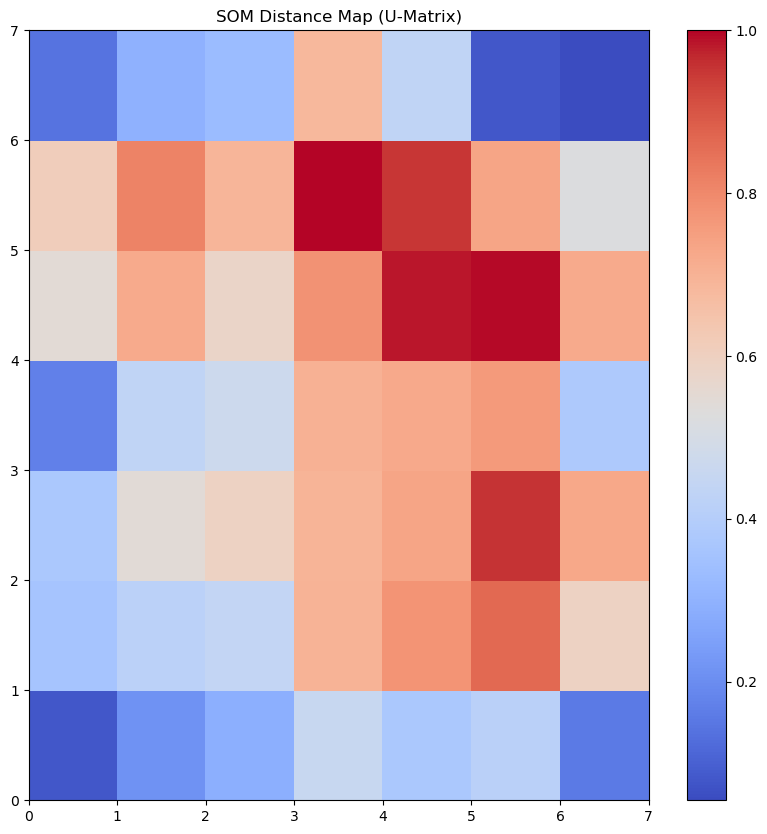

Cluster assignments for students:
Student 1 is in cluster (5, 6)
Student 2 is in cluster (4, 3)
Student 3 is in cluster (2, 6)
Student 4 is in cluster (6, 3)
Student 5 is in cluster (0, 3)
Student 6 is in cluster (2, 1)
Student 7 is in cluster (0, 6)
Student 8 is in cluster (4, 1)
Student 9 is in cluster (0, 0)
Student 10 is in cluster (6, 0)
Student 11 is in cluster (2, 4)


In [5]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the data
def load_and_preprocess_data(file_path):
    # Load the dataset
    data = pd.read_csv(file_path)

    # Drop non-relevant columns (e.g., student IDs, result if present)
    if 'st_id' in data.columns:
        data = data.drop(columns=['st_id'])
    if 'result' in data.columns:
        data = data.drop(columns=['result'])
    
    # Normalize the data using MinMaxScaler to scale marks between 0 and 1
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled, scaler

# Step 2: Train the KSOM
def train_som(data, x=7, y=7, input_len=None, sigma=1.0, learning_rate=0.5, iterations=1000):
    # Initialize MiniSom
    som = MiniSom(x=x, y=y, input_len=input_len, sigma=sigma, learning_rate=learning_rate)
    som.random_weights_init(data)
    
    # Train the SOM
    som.train_random(data, iterations)
    
    return som

# Step 3: Visualize the clusters
def visualize_som(som):
    plt.figure(figsize=(10, 10))
    plt.pcolor(som.distance_map().T, cmap='coolwarm')  # Plot U-Matrix
    plt.colorbar()
    plt.title('SOM Distance Map (U-Matrix)')
    plt.show()

# Step 4: Assign students to clusters
def assign_clusters(som, data):
    clusters = []
    for sample in data:
        cluster = som.winner(sample)
        clusters.append(cluster)
    return clusters

# Step 5: Main function to execute the KSOM clustering
def main():
    # Define file path for the dataset (replace with your actual file path)
    file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    
    # Step 1: Load and preprocess the data
    data_scaled, scaler = load_and_preprocess_data(file_path)
    
    # Step 2: Train the KSOM
    input_len = data_scaled.shape[1]  # Number of features (marks)
    som = train_som(data_scaled, x=7, y=7, input_len=input_len)
    
    # Step 3: Visualize the trained SOM
    visualize_som(som)
    
    # Step 4: Assign clusters to students
    clusters = assign_clusters(som, data_scaled)
    
    # Step 5: Output the clusters
    print("Cluster assignments for students:")
    for i, cluster in enumerate(clusters):
        print(f"Student {i + 1} is in cluster {cluster}")

if __name__ == "__main__":
    main()


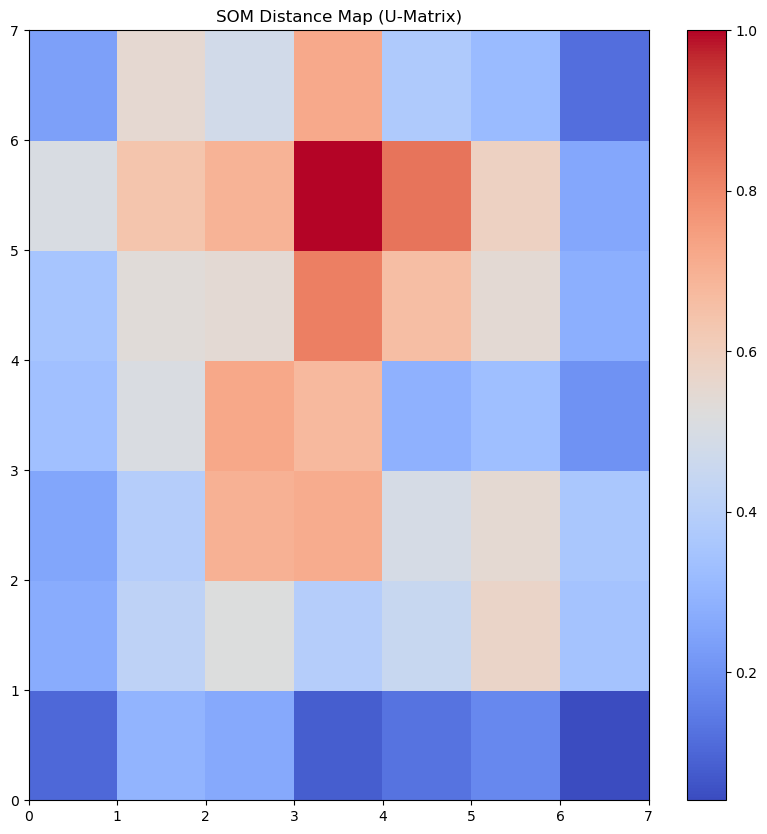

Student Cluster Assignments and Pass/Fail Results:
Student 1 is in Cluster (6, 3) and has Pass
Student 2 is in Cluster (4, 6) and has Pass
Student 3 is in Cluster (1, 4) and has Fail
Student 4 is in Cluster (1, 2) and has Pass
Student 5 is in Cluster (6, 5) and has Pass
Student 6 is in Cluster (6, 0) and has Pass
Student 7 is in Cluster (2, 5) and has Fail
Student 8 is in Cluster (0, 6) and has Pass
Student 9 is in Cluster (0, 0) and has Pass
Student 10 is in Cluster (4, 3) and has Pass
Student 11 is in Cluster (3, 0) and has Pass


In [7]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the data
def load_and_preprocess_data(file_path):
    # Load the dataset
    data = pd.read_csv(file_path)

    # Drop non-relevant columns (e.g., student IDs, result if present)
    if 'st_id' in data.columns:
        data = data.drop(columns=['st_id'])
    
    # Remove the 'result' column if it's used as a label
    if 'result' in data.columns:
        result = data['result']
        data = data.drop(columns=['result'])
    else:
        result = None
    
    # Normalize the data using MinMaxScaler to scale marks between 0 and 1
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled, result, scaler

# Step 2: Train the KSOM
def train_som(data, x=7, y=7, input_len=None, sigma=1.0, learning_rate=0.5, iterations=1000):
    # Initialize MiniSom
    som = MiniSom(x=x, y=y, input_len=input_len, sigma=sigma, learning_rate=learning_rate)
    som.random_weights_init(data)
    
    # Train the SOM
    som.train_random(data, iterations)
    
    return som

# Step 3: Visualize the clusters
def visualize_som(som):
    plt.figure(figsize=(10, 10))
    plt.pcolor(som.distance_map().T, cmap='coolwarm')  # Plot U-Matrix
    plt.colorbar()
    plt.title('SOM Distance Map (U-Matrix)')
    plt.show()

# Step 4: Assign students to clusters
def assign_clusters(som, data):
    clusters = []
    for sample in data:
        cluster = som.winner(sample)
        clusters.append(cluster)
    return clusters

# Step 5: Check Pass/Fail based on threshold
def determine_pass_fail(data, clusters, threshold=0.4):
    results = []
    for i, sample in enumerate(data):
        # Calculate average marks (since data is normalized, it's between 0 and 1)
        avg_marks = sample.mean()
        
        # Determine pass/fail based on average marks and threshold
        if avg_marks >= threshold:
            results.append((i + 1, clusters[i], "Pass"))
        else:
            results.append((i + 1, clusters[i], "Fail"))
    
    return results

# Step 6: Main function to execute the KSOM clustering
def main():
    # Define file path for the dataset (replace with your actual file path)
    file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    
    # Step 1: Load and preprocess the data
    data_scaled, result, scaler = load_and_preprocess_data(file_path)
    
    # Step 2: Train the KSOM
    input_len = data_scaled.shape[1]  # Number of features (marks)
    som = train_som(data_scaled, x=7, y=7, input_len=input_len)
    
    # Step 3: Visualize the trained SOM
    visualize_som(som)
    
    # Step 4: Assign clusters to students
    clusters = assign_clusters(som, data_scaled)
    
    # Step 5: Determine pass/fail based on average marks (using a threshold of 40% as example)
    pass_fail_results = determine_pass_fail(data_scaled, clusters, threshold=0.4)
    
    # Step 6: Output the results
    print("Student Cluster Assignments and Pass/Fail Results:")
    for student_id, cluster, status in pass_fail_results:
        print(f"Student {student_id} is in Cluster {cluster} and has {status}")

if __name__ == "__main__":
    main()


In [9]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the data
def load_and_preprocess_data(file_path):
    # Load the dataset
    data = pd.read_csv(file_path)

    # Drop non-relevant columns (e.g., student IDs, result if present)
    if 'st_id' in data.columns:
        data = data.drop(columns=['st_id'])
    
    # Remove the 'result' column if it's used as a label
    if 'result' in data.columns:
        result = data['result']
        data = data.drop(columns=['result'])
    else:
        result = None
    
    # Normalize the data using MinMaxScaler to scale marks between 0 and 1
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled, result, scaler

# Step 2: Train the KSOM with two clusters
def train_som(data, x=1, y=2, input_len=None, sigma=1.0, learning_rate=0.5, iterations=1000):
    # Initialize MiniSom with 1x2 grid (two clusters)
    som = MiniSom(x=x, y=y, input_len=input_len, sigma=sigma, learning_rate=learning_rate)
    som.random_weights_init(data)
    
    # Train the SOM
    som.train_random(data, iterations)
    
    return som

# Step 3: Assign students to Pass/Fail clusters
def assign_pass_fail_clusters(som, data):
    clusters = []
    for sample in data:
        cluster = som.winner(sample)
        # Assign Pass to one cluster (e.g., cluster (0, 0)) and Fail to the other (e.g., cluster (0, 1))
        if cluster == (0, 0):
            clusters.append("Pass")
        else:
            clusters.append("Fail")
    return clusters

# Step 4: Main function to execute the KSOM clustering
def main():
    # Define file path for the dataset (replace with your actual file path)
    file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    
    # Step 1: Load and preprocess the data
    data_scaled, result, scaler = load_and_preprocess_data(file_path)
    
    # Step 2: Train the KSOM (1x2 grid for two clusters)
    input_len = data_scaled.shape[1]  # Number of features (marks)
    som = train_som(data_scaled, x=1, y=2, input_len=input_len)
    
    # Step 3: Assign clusters as Pass/Fail
    pass_fail_clusters = assign_pass_fail_clusters(som, data_scaled)
    
    # Step 4: Output the cluster results
    print("Student Cluster Assignments (Pass/Fail):")
    for i, status in enumerate(pass_fail_clusters):
        print(f"Student {i + 1} has {status}")

if __name__ == "__main__":
    main()


Student Cluster Assignments (Pass/Fail):
Student 1 has Pass
Student 2 has Pass
Student 3 has Fail
Student 4 has Pass
Student 5 has Pass
Student 6 has Pass
Student 7 has Fail
Student 8 has Pass
Student 9 has Pass
Student 10 has Pass
Student 11 has Pass


In [11]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the data
def load_and_preprocess_data(file_path):
    # Load the dataset
    data = pd.read_csv(file_path)

    # Drop non-relevant columns (e.g., student IDs, result if present)
    if 'st_id' in data.columns:
        data = data.drop(columns=['st_id'])
    
    # Remove the 'result' column if it's used as a label
    if 'result' in data.columns:
        result = data['result']
        data = data.drop(columns=['result'])
    else:
        result = None
    
    # Normalize the data using MinMaxScaler to scale marks between 0 and 1
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled, result, scaler

# Step 2: Train the KSOM with two clusters (1x2 grid)
def train_som(data, x=1, y=2, input_len=None, sigma=1.0, learning_rate=0.5, iterations=1000):
    # Initialize MiniSom with 1x2 grid (two clusters)
    som = MiniSom(x=x, y=y, input_len=input_len, sigma=sigma, learning_rate=learning_rate)
    som.random_weights_init(data)
    
    # Train the SOM
    som.train_random(data, iterations)
    
    return som

# Step 3: Assign students to Pass/Fail clusters
def assign_pass_fail_clusters(som, data):
    clusters = []
    for sample in data:
        cluster = som.winner(sample)
        # Assign Pass to one cluster (e.g., cluster (0, 0)) and Fail to the other (e.g., cluster (0, 1))
        if cluster == (0, 0):
            clusters.append("Pass")
        else:
            clusters.append("Fail")
    return clusters

# Step 4: Main function to execute the KSOM clustering on both training and testing datasets
def main():
    # Define file paths for training and testing datasets
    train_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\training_dataset_students(1000).csv'
    test_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    
    # Step 1: Load and preprocess the training data
    print("Loading and preprocessing training data...")
    train_data_scaled, _, _ = load_and_preprocess_data(train_file_path)
    
    # Step 2: Train the KSOM (1x2 grid for two clusters) using training data
    print("Training the KSOM model...")
    input_len = train_data_scaled.shape[1]  # Number of features (marks)
    som = train_som(train_data_scaled, x=1, y=2, input_len=input_len)
    
    # Step 3: Load and preprocess the testing data
    print("Loading and preprocessing testing data...")
    test_data_scaled, _, _ = load_and_preprocess_data(test_file_path)
    
    # Step 4: Assign clusters (Pass/Fail) to the testing dataset
    print("Classifying students in the testing dataset...")
    pass_fail_clusters = assign_pass_fail_clusters(som, test_data_scaled)
    
    # Step 5: Output the cluster results for the testing dataset
    print("\nStudent Cluster Assignments (Pass/Fail) in Testing Dataset:")
    for i, status in enumerate(pass_fail_clusters):
        print(f"Student {i + 1} has {status}")

if __name__ == "__main__":
    main()


Loading and preprocessing training data...
Training the KSOM model...
Loading and preprocessing testing data...
Classifying students in the testing dataset...

Student Cluster Assignments (Pass/Fail) in Testing Dataset:
Student 1 has Pass
Student 2 has Pass
Student 3 has Fail
Student 4 has Fail
Student 5 has Pass
Student 6 has Pass
Student 7 has Fail
Student 8 has Pass
Student 9 has Pass
Student 10 has Pass
Student 11 has Pass


In [13]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

# Step 1: Load and preprocess the data
def load_and_preprocess_data(file_path):
    # Load the dataset
    data = pd.read_csv(file_path)

    # Drop non-relevant columns (e.g., student IDs, result if present)
    if 'st_id' in data.columns:
        data = data.drop(columns=['st_id'])
    
    # Remove the 'result' column if it's used as a label
    if 'result' in data.columns:
        result = data['result']
        data = data.drop(columns=['result'])
    else:
        result = None
    
    # Normalize the data using MinMaxScaler to scale marks between 0 and 1
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled, result, scaler

# Step 2: Train the KSOM with two clusters (1x2 grid)
def train_som(data, x=1, y=2, input_len=None, sigma=1.0, learning_rate=0.5, iterations=1000):
    # Initialize MiniSom with 1x2 grid (two clusters)
    som = MiniSom(x=x, y=y, input_len=input_len, sigma=sigma, learning_rate=learning_rate)
    som.random_weights_init(data)
    
    # Train the SOM
    som.train_random(data, iterations)
    
    return som

# Step 3: Assign students to Pass/Fail clusters based on marks condition
def assign_pass_fail_clusters(som, data):
    clusters = []
    for sample in data:
        # Check for passing condition (marks less than 40 in any subject)
        if any(mark < 0.4 for mark in sample):  # Normalized marks (0-1)
            clusters.append("Fail")
        else:
            clusters.append("Pass")
    return clusters

# Step 4: Main function to execute the KSOM clustering on both training and testing datasets
def main():
    # Define file paths for training and testing datasets
    train_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\training_dataset_students(1000).csv'
    test_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    
    # Step 1: Load and preprocess the training data
    print("Loading and preprocessing training data...")
    train_data_scaled, _, _ = load_and_preprocess_data(train_file_path)
    
    # Step 2: Train the KSOM (1x2 grid for two clusters) using training data
    print("Training the KSOM model...")
    input_len = train_data_scaled.shape[1]  # Number of features (marks)
    som = train_som(train_data_scaled, x=1, y=2, input_len=input_len)
    
    # Step 3: Load and preprocess the testing data
    print("Loading and preprocessing testing data...")
    test_data_scaled, _, _ = load_and_preprocess_data(test_file_path)
    
    # Step 4: Assign clusters (Pass/Fail) to the testing dataset
    print("Classifying students in the testing dataset based on marks...")
    pass_fail_clusters = assign_pass_fail_clusters(som, test_data_scaled)
    
    # Step 5: Output the cluster results for the testing dataset
    print("\nStudent Cluster Assignments (Pass/Fail) in Testing Dataset:")
    for i, status in enumerate(pass_fail_clusters):
        print(f"Student {i + 1} has {status}")

if __name__ == "__main__":
    main()


Loading and preprocessing training data...
Training the KSOM model...
Loading and preprocessing testing data...
Classifying students in the testing dataset based on marks...

Student Cluster Assignments (Pass/Fail) in Testing Dataset:
Student 1 has Fail
Student 2 has Pass
Student 3 has Fail
Student 4 has Fail
Student 5 has Fail
Student 6 has Fail
Student 7 has Fail
Student 8 has Fail
Student 9 has Fail
Student 10 has Fail
Student 11 has Fail


In [15]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

# Step 1: Load and preprocess the data
def load_and_preprocess_data(file_path):
    # Load the dataset
    data = pd.read_csv(file_path)

    # Drop non-relevant columns (e.g., student IDs)
    if 'st_id' in data.columns:
        data = data.drop(columns=['st_id'])
    
    # Remove the 'result' column if it's used as a label
    if 'result' in data.columns:
        result = data['result']
        data = data.drop(columns=['result'])
    else:
        result = None
    
    # Normalize the data using MinMaxScaler to scale marks between 0 and 1
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled, result, scaler

# Step 2: Train the KSOM with a 1x2 grid
def train_som(data, x=1, y=2, input_len=None, sigma=1.0, learning_rate=0.5, iterations=2000):
    # Initialize MiniSom with 1x2 grid (two clusters)
    som = MiniSom(x=x, y=y, input_len=input_len, sigma=sigma, learning_rate=learning_rate)
    som.random_weights_init(data)
    
    # Train the SOM
    som.train_random(data, iterations)
    
    return som

# Step 3: Assign students to Pass/Fail clusters based on marks condition
def assign_pass_fail_clusters(som, data):
    clusters = []
    for sample in data:
        # Check for passing condition (marks less than 40 in any subject)
        if any(mark < 0.4 for mark in sample):  # Normalized marks (0-1)
            clusters.append("Fail")
        else:
            clusters.append("Pass")
    return clusters

# Step 4: Main function to execute the KSOM clustering on both training and testing datasets
def main():
    # Define file paths for training and testing datasets
    train_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\training_dataset_students(1000).csv'
    test_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    
    # Step 1: Load and preprocess the training data
    print("Loading and preprocessing training data...")
    train_data_scaled, _, _ = load_and_preprocess_data(train_file_path)
    
    # Step 2: Train the KSOM (1x2 grid for two clusters) using training data
    print("Training the KSOM model...")
    input_len = train_data_scaled.shape[1]  # Number of features (marks)
    som = train_som(train_data_scaled, x=1, y=2, input_len=input_len)
    
    # Step 3: Load and preprocess the testing data
    print("Loading and preprocessing testing data...")
    test_data_scaled, _, _ = load_and_preprocess_data(test_file_path)
    
    # Step 4: Assign clusters (Pass/Fail) to the testing dataset
    print("Classifying students in the testing dataset based on marks...")
    pass_fail_clusters = assign_pass_fail_clusters(som, test_data_scaled)
    
    # Step 5: Output the cluster results for the testing dataset
    print("\nStudent Cluster Assignments (Pass/Fail) in Testing Dataset:")
    for i, status in enumerate(pass_fail_clusters):
        print(f"Student {i + 1} has {status}")

if __name__ == "__main__":
    main()


Loading and preprocessing training data...
Training the KSOM model...
Loading and preprocessing testing data...
Classifying students in the testing dataset based on marks...

Student Cluster Assignments (Pass/Fail) in Testing Dataset:
Student 1 has Fail
Student 2 has Pass
Student 3 has Fail
Student 4 has Fail
Student 5 has Fail
Student 6 has Fail
Student 7 has Fail
Student 8 has Fail
Student 9 has Fail
Student 10 has Fail
Student 11 has Fail


In [17]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

# Step 1: Load and preprocess the data
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)

    if 'st_id' in data.columns:
        data = data.drop(columns=['st_id'])
    
    # Normalizing the data
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled

# Step 2: Train the KSOM with a 1x2 grid
def train_som(data, x=1, y=2, input_len=None, iterations=2000):
    som = MiniSom(x=x, y=y, input_len=input_len, sigma=1.0, learning_rate=0.5)
    som.random_weights_init(data)
    som.train_random(data, iterations)
    return som

# Step 3: Main function to execute the KSOM clustering on both datasets
def main():
    train_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\training_dataset_students(1000).csv'
    test_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    
    # Load and preprocess training data
    train_data_scaled = load_and_preprocess_data(train_file_path)
    
    # Train the KSOM
    input_len = train_data_scaled.shape[1]
    som = train_som(train_data_scaled, x=1, y=2, input_len=input_len)
    
    # Load and preprocess testing data
    test_data_scaled = load_and_preprocess_data(test_file_path)
    
    # Assign clusters for the testing dataset
    print("Classifying students in the testing dataset...")
    for idx, sample in enumerate(test_data_scaled):
        cluster = som.winner(sample)  # Find the winning node for the sample
        print(f"Student {idx + 1} belongs to Cluster: {cluster}")

    # Optional: Analyze clusters after training
    # (e.g., calculate average marks per cluster)
    
if __name__ == "__main__":
    main()


Classifying students in the testing dataset...
Student 1 belongs to Cluster: (0, 1)
Student 2 belongs to Cluster: (0, 0)
Student 3 belongs to Cluster: (0, 1)
Student 4 belongs to Cluster: (0, 1)
Student 5 belongs to Cluster: (0, 0)
Student 6 belongs to Cluster: (0, 1)
Student 7 belongs to Cluster: (0, 1)
Student 8 belongs to Cluster: (0, 1)
Student 9 belongs to Cluster: (0, 1)
Student 10 belongs to Cluster: (0, 1)
Student 11 belongs to Cluster: (0, 0)


In [19]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

# Step 1: Load and preprocess the data
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)

    if 'st_id' in data.columns:
        data = data.drop(columns=['st_id'])
    
    # Normalizing the data
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled

# Step 2: Train the KSOM with a 1x2 grid
def train_som(data, x=1, y=2, input_len=None, iterations=2000):
    som = MiniSom(x=x, y=y, input_len=input_len, sigma=1.0, learning_rate=0.5)
    som.random_weights_init(data)
    som.train_random(data, iterations)
    return som

# Step 3: Analyze and classify students based on marks
def classify_students(som, test_data):
    classifications = []
    
    for sample in test_data:
        cluster = som.winner(sample)  # Find the winning node for the sample
        # Check for passing condition (marks less than 40)
        if any(mark < 0.4 for mark in sample):  # Normalized condition
            classifications.append((cluster, "Fail"))
        else:
            classifications.append((cluster, "Pass"))
    
    return classifications

# Step 4: Main function to execute the KSOM clustering on both datasets
def main():
    train_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\training_dataset_students(1000).csv'
    test_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    
    # Load and preprocess training data
    train_data_scaled = load_and_preprocess_data(train_file_path)
    
    # Train the KSOM
    input_len = train_data_scaled.shape[1]
    som = train_som(train_data_scaled, x=1, y=2, input_len=input_len)
    
    # Load and preprocess testing data
    test_data_scaled = load_and_preprocess_data(test_file_path)
    
    # Classify students in the testing dataset
    print("Classifying students in the testing dataset...")
    results = classify_students(som, test_data_scaled)
    
    # Output the cluster results for the testing dataset
    print("\nStudent Cluster Assignments (Pass/Fail) in Testing Dataset:")
    for idx, (cluster, status) in enumerate(results):
        print(f"Student {idx + 1} belongs to Cluster {cluster} and is {status}")

if __name__ == "__main__":
    main()


Classifying students in the testing dataset...

Student Cluster Assignments (Pass/Fail) in Testing Dataset:
Student 1 belongs to Cluster (0, 0) and is Fail
Student 2 belongs to Cluster (0, 1) and is Pass
Student 3 belongs to Cluster (0, 0) and is Fail
Student 4 belongs to Cluster (0, 0) and is Fail
Student 5 belongs to Cluster (0, 1) and is Fail
Student 6 belongs to Cluster (0, 0) and is Fail
Student 7 belongs to Cluster (0, 0) and is Fail
Student 8 belongs to Cluster (0, 0) and is Fail
Student 9 belongs to Cluster (0, 0) and is Fail
Student 10 belongs to Cluster (0, 0) and is Fail
Student 11 belongs to Cluster (0, 1) and is Fail


In [21]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

# Step 1: Load and preprocess the data
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)

    if 'st_id' in data.columns:
        data = data.drop(columns=['st_id'])
    
    # Normalizing the data
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled

# Step 2: Train the KSOM with a 1x2 grid
def train_som(data, x=1, y=2, input_len=None, iterations=2000):
    som = MiniSom(x=x, y=y, input_len=input_len, sigma=1.0, learning_rate=0.5)
    som.random_weights_init(data)
    som.train_random(data, iterations)
    return som

# Step 3: Analyze and classify students based on marks
def classify_students(som, test_data):
    classifications = []
    
    for sample in test_data:
        cluster = som.winner(sample)  # Find the winning node for the sample
        # Check for passing condition (marks less than 40)
        if any(mark < 0.4 for mark in sample):  # Normalized condition
            classifications.append((cluster, "Fail"))
        else:
            classifications.append((cluster, "Pass"))
    
    return classifications

# Step 4: Output final trained weights
def print_final_weights(som):
    print("\nFinal trained weights:")
    for i, weight_vector in enumerate(som.get_weights()):
        print(f"Cluster {i} weights: {weight_vector.flatten().tolist()}")

# Step 5: Main function to execute the KSOM clustering on both datasets
def main():
    train_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\training_dataset_students(1000).csv'
    test_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    
    # Load and preprocess training data
    train_data_scaled = load_and_preprocess_data(train_file_path)
    
    # Train the KSOM
    input_len = train_data_scaled.shape[1]
    som = train_som(train_data_scaled, x=1, y=2, input_len=input_len)
    
    # Load and preprocess testing data
    test_data_scaled = load_and_preprocess_data(test_file_path)
    
    # Classify students in the testing dataset
    print("Classifying students in the testing dataset...")
    results = classify_students(som, test_data_scaled)
    
    # Output the cluster results for the testing dataset
    print("\nStudent Cluster Assignments (Pass/Fail) in Testing Dataset:")
    for idx, (cluster, status) in enumerate(results):
        print(f"Student {idx + 1} belongs to Cluster {cluster} and is {status}")

    # Output the final trained weights
    print_final_weights(som)

if __name__ == "__main__":
    main()


Classifying students in the testing dataset...

Student Cluster Assignments (Pass/Fail) in Testing Dataset:
Student 1 belongs to Cluster (0, 0) and is Fail
Student 2 belongs to Cluster (0, 1) and is Pass
Student 3 belongs to Cluster (0, 0) and is Fail
Student 4 belongs to Cluster (0, 0) and is Fail
Student 5 belongs to Cluster (0, 1) and is Fail
Student 6 belongs to Cluster (0, 0) and is Fail
Student 7 belongs to Cluster (0, 0) and is Fail
Student 8 belongs to Cluster (0, 0) and is Fail
Student 9 belongs to Cluster (0, 0) and is Fail
Student 10 belongs to Cluster (0, 0) and is Fail
Student 11 belongs to Cluster (0, 1) and is Fail

Final trained weights:
Cluster 0 weights: [0.39771024506824154, 0.3733045440978392, 0.46384989862039666, 0.43145332471891423, 0.4546932755775692, 0.6137939306927394, 0.014144085529909606, 0.679238539277703, 0.5955002842525051, 0.6420994836472402, 0.6479302114892508, 0.6455130949803234, 0.5942219636611898, 0.9925578831738278]


In [23]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

# Step 1: Load and preprocess the data
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)

    if 'st_id' in data.columns:
        data = data.drop(columns=['st_id'])
    
    # Normalizing the data
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled

# Step 2: Train the KSOM with a 1x2 grid
def train_som(data, x=1, y=2, input_len=None, iterations=2000):
    som = MiniSom(x=x, y=y, input_len=input_len, sigma=1.0, learning_rate=0.5)
    som.random_weights_init(data)
    som.train_random(data, iterations)
    return som

# Step 3: Analyze and classify students based on marks
def classify_students(som, test_data):
    classifications = []
    
    for sample in test_data:
        cluster = som.winner(sample)  # Find the winning node for the sample
        # Check for passing condition (marks less than 40)
        if any(mark < 0.4 for mark in sample):  # Normalized condition
            classifications.append((cluster, "Fail"))
        else:
            classifications.append((cluster, "Pass"))
    
    return classifications

# Step 4: Output final trained weights
def print_final_weights(som):
    print("\nFinal trained weights:")
    for i, weight_vector in enumerate(som.get_weights()):
        print(f"Cluster {i} weights: {weight_vector.flatten().tolist()}")

# Step 5: Main function to execute the KSOM clustering on both datasets
def main():
    train_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\training_dataset_students(1000).csv'
    test_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    
    # Load and preprocess training data
    train_data_scaled = load_and_preprocess_data(train_file_path)
    
    # Train the KSOM
    input_len = train_data_scaled.shape[1]
    som = train_som(train_data_scaled, x=1, y=2, input_len=input_len)
    
    # Load and preprocess testing data
    test_data_scaled = load_and_preprocess_data(test_file_path)
    
    # Classify students in the testing dataset
    print("Classifying students in the testing dataset...")
    results = classify_students(som, test_data_scaled)
    
    # Output the cluster results for the testing dataset
    print("\nStudent Cluster Assignments (Pass/Fail) in Testing Dataset:")
    for idx, (cluster, status) in enumerate(results):
        print(f"Student {idx + 1} has {status}")

    # Output the final trained weights
    print_final_weights(som)

if __name__ == "__main__":
    main()


Classifying students in the testing dataset...

Student Cluster Assignments (Pass/Fail) in Testing Dataset:
Student 1 has Fail
Student 2 has Pass
Student 3 has Fail
Student 4 has Fail
Student 5 has Fail
Student 6 has Fail
Student 7 has Fail
Student 8 has Fail
Student 9 has Fail
Student 10 has Fail
Student 11 has Fail

Final trained weights:
Cluster 0 weights: [0.5658554975278278, 0.33898250116534706, 0.33940144507545, 0.5118113100597199, 0.3912480667019919, 0.5769906476558846, 0.0067177903203944015, 0.5950987530437714, 0.6668479142800512, 0.5641427869705018, 0.6339037378287202, 0.6640977185457835, 0.5872078347775623, 0.9843598818488292]


In [25]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

# Step 1: Load and preprocess the data
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)

    if 'st_id' in data.columns:
        data = data.drop(columns=['st_id'])
    
    # Normalizing the data
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled

# Step 2: Train the KSOM with a 1x2 grid
def train_som(data, x=1, y=2, input_len=None, iterations=2000):
    som = MiniSom(x=x, y=y, input_len=input_len, sigma=1.0, learning_rate=0.5)
    som.random_weights_init(data)
    som.train_random(data, iterations)
    return som

# Step 3: Analyze and classify students based on marks
def classify_students(som, test_data):
    classifications = []
    
    for sample in test_data:
        cluster = som.winner(sample)  # Find the winning node for the sample
        # Check for passing condition (marks less than 40)
        if any(mark < 0.4 for mark in sample):  # Normalized condition
            classifications.append((cluster, "Fail"))
        else:
            classifications.append((cluster, "Pass"))
    
    return classifications

# Step 5: Main function to execute the KSOM clustering on both datasets
def main():
    train_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\training_dataset_students(1000).csv'
    test_file_path = r'E:\SRM\Soft Computing\Lab 9 - 15th Oct\students_testing.csv'
    
    # Load and preprocess training data
    train_data_scaled = load_and_preprocess_data(train_file_path)
    
    # Train the KSOM
    input_len = train_data_scaled.shape[1]
    som = train_som(train_data_scaled, x=1, y=2, input_len=input_len)
    
    # Load and preprocess testing data
    test_data_scaled = load_and_preprocess_data(test_file_path)
    
    # Classify students in the testing dataset
    print("Classifying students in the testing dataset...")
    results = classify_students(som, test_data_scaled)
    
    # Output the cluster results for the testing dataset
    print("\nStudent Cluster Assignments (Pass/Fail) in Testing Dataset:")
    for idx, (cluster, status) in enumerate(results):
        print(f"Student {idx + 1} has {status}")

if __name__ == "__main__":
    main()


Classifying students in the testing dataset...

Student Cluster Assignments (Pass/Fail) in Testing Dataset:
Student 1 has Fail
Student 2 has Pass
Student 3 has Fail
Student 4 has Fail
Student 5 has Fail
Student 6 has Fail
Student 7 has Fail
Student 8 has Fail
Student 9 has Fail
Student 10 has Fail
Student 11 has Fail
